/tmp/ipykernel_162142/100187314.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax['a'].set_xticklabels(empty_string_labels)
/tmp/ipykernel_162142/100187314.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax['e'].set_xticklabels(empty_string_labels)


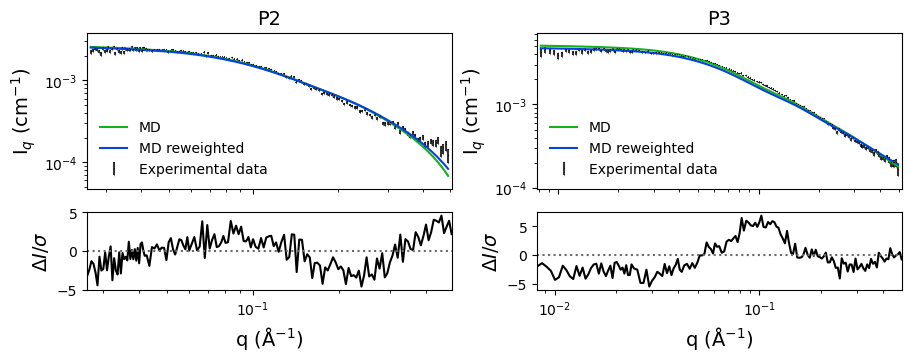

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #https://xkcd.com/color/rgb/
from matplotlib.ticker import FormatStrFormatter

%matplotlib inline

file_list = [
    'BME_P2/data.dat',
    'BME_P3/data.dat'
]

c1 = sns.xkcd_rgb["black"]
c2 = sns.xkcd_rgb["red"]
c3 = sns.xkcd_rgb["sky blue"]
c4 = sns.xkcd_rgb["green"]
c5 = sns.xkcd_rgb["orange"]
c6 = sns.xkcd_rgb["blue"]
c7 = sns.xkcd_rgb["denim blue"]
color_list = [c1,c2,c3,c4,c5,c6]

#fig, ax = plt.subplots(nrows=4, ncols=1, dpi=300,figsize=(5.5,6.6), gridspec_kw=dict(height_ratios=[1.5,0.5,0.5,0.5],hspace=0.2),constrained_layout=True)
fig, ax = plt.subplot_mosaic([['a', 'a', 'e', 'e'],
                               ['a', 'a', 'e', 'e'],
                               ['b','b', 'f','f']],
                              figsize=(9, 3.5), layout="constrained")

#plot saxs fitting
data = np.loadtxt(file_list[0])
x = data[:,0]
avg_exp = data[:,1]
sigma_exp = data[:,2]
avg_calc = data[:,3]
avg_calc_rew = data[:,4]

ax['a'].errorbar(x, avg_exp,yerr=sigma_exp,fmt=',', capsize=0.2, color=c1,alpha=0.8,label='Experimental data')
ax['a'].plot(x, avg_calc,color=c4,label='MD')
ax['a'].plot(x, avg_calc_rew,color=c6,label='MD reweighted')

#ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
#ax.set_ylim(0,1.05)
#ax.set_xlim(0.,150.)
ax['a'].set_ylabel(r'I$_{q}$ (cm$^{-1}$)', fontsize=14)
ax['a'].set_xscale('log')
ax['a'].set_yscale('log')
ax['a'].legend(frameon=False)


#trick to hide labels in ax[1]
labels = [item.get_text() for item in ax['a'].get_xticklabels()]
empty_string_labels = ['']*len(labels)
ax['a'].set_xticklabels(empty_string_labels)
ax['a'].margins(x=0.01,y=0.1)
ax['a'].set_title('P2', fontsize=14)

#plot residuals
ax['b'].plot(x, (avg_exp-avg_calc)/sigma_exp, 'k', label='residuals')
ax['b'].set_ylabel(r'$\Delta I$/$\sigma$', fontsize=14)
ax['b'].set_xlabel(r'q (Å$^{-1}$)', fontsize=14)
ax['b'].set_xscale('log')
ax['b'].hlines(0,x.min(),x.max(), color='dimgray', linestyles='dotted')
ax['b'].set_xlim(x.min(),x.max())
#ax['f'].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
#ax['b'].set_ylim(-55,55)
#ax['f'].hlines(AA10_data[:,0].min(),AA10_data[:,0].max(),0, color='dimgray', linestyles='dotted')

# dimer data
data = np.loadtxt(file_list[1])
x = data[:,0]
avg_exp = data[:,1]
sigma_exp = data[:,2]
avg_calc = data[:,3]
avg_calc_rew = data[:,4]

ax['e'].errorbar(x, avg_exp,yerr=sigma_exp,fmt=',', capsize=0.2, color=c1,alpha=0.8,label='Experimental data')
ax['e'].plot(x, avg_calc,color=c4,label='MD')
ax['e'].plot(x, avg_calc_rew,color=c6,label='MD reweighted')

#ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
#ax.set_ylim(0,1.05)
#ax.set_xlim(0.,150.)
ax['e'].set_ylabel(r'I$_{q}$ (cm$^{-1}$)', fontsize=14)
ax['e'].set_xscale('log')
ax['e'].set_yscale('log')
ax['e'].legend(frameon=False)


#trick to hide labels in ax[1]
labels = [item.get_text() for item in ax['a'].get_xticklabels()]
empty_string_labels = ['']*len(labels)
ax['e'].set_xticklabels(empty_string_labels)
ax['e'].margins(x=0.01,y=0.1)
ax['e'].set_title('P3', fontsize=14)

#plot residuals
ax['f'].plot(x, (avg_exp-avg_calc)/sigma_exp, 'k', label='residuals')
ax['f'].set_ylabel(r'$\Delta I$/$\sigma$', fontsize=14)
ax['f'].set_xlabel(r'q (Å$^{-1}$)', fontsize=14)
ax['f'].set_xscale('log')
ax['f'].hlines(0,x.min(),x.max(), color='dimgray', linestyles='dotted')
ax['f'].set_xlim(x.min(),x.max())
plt.savefig('SAXS_fitting_v1.png', dpi=300)
plt.show()
